In [1]:
import torch
import spikingjelly
from spikingjelly.activation_based import neuron, functional
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print(f"PyTorch version     : {torch.__version__}")
# print(f"SpikingJelly version: {spikingjelly.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")
print(f"Device we'll use    : {'cuda' if torch.cuda.is_available() else 'cpu'}")
print("\n✅ All imports successful")

PyTorch version     : 2.10.0+cpu
CUDA available      : False
Device we'll use    : cpu

✅ All imports successful


#### Create one LIF neuron, understand parameters

In [6]:
'''      LIF = Leaky Integrate-and-Fire
  The three parameters you must understand:

#   tau         — membrane time constant
                 How fast the neuron "forgets" old input
                 tau=2.0 → forgets quickly (short memory)
                 tau=5.0 → forgets slowly  (long memory)

#   v_threshold — voltage required to fire a spike
                 Lower  → fires more easily (sensitive neuron)
                 Higher → fires less often  (selective neuron)

#   v_reset     — voltage the neuron resets to after firing
                 Usually 0.0 (hard reset) or v_threshold (soft reset)     '''

lif = neuron.LIFNode(     # LIFNode is a class in SpikingJelly framework 
    tau         = 2.0,    # membrane time constant
    v_threshold = 0.2,    # fire when voltage crosses this 
    v_reset     = 0.0,    # reset this value, after firing
)

print("LIF Neuron created:")
print(lif)
print(f"\n  tau         : {lif.tau}")
print(f"  v_threshold : {lif.v_threshold}")
print(f"  v_reset     : {lif.v_reset}")

LIF Neuron created:
LIFNode(
  v_threshold=0.2, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
  (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
)

  tau         : 2.0
  v_threshold : 0.2
  v_reset     : 0.0


#### Send a simple input signal through the LIF neuron

In [7]:
# Our input: a sequence of 5 current values
# Think of these as "how much signal arrives at this timestep"
# Values between 0 and 1 — like normalized price returns

input_signal = [0.1, 0.5, 0.9, 0.3, 0.7]

print("=" * 50)
print("SINGLE LIF NEURON — STEP BY STEP")
print("=" * 50)
print(f"{'Step':>5}  {'Input':>8}  {'Voltage':>10}  {'Spike':>7}")
print("-" * 50)

# Reset neuron state before running
functional.reset_net(lif)    # It just clears all previous data like clearning catche 

voltages = []
spikes   = []

for t, x in enumerate(input_signal):
    # Convert scalar to tensor (SpikingJelly expects tensors)
    x_tensor = torch.tensor([[x]], dtype=torch.float32)

    # Step the neuron forward one timestep
    spike_out = lif(x_tensor)   # passing input current of type TensorFloat

    v     = lif.v.item()       # current membrane voltage ; .item() --> just converts tensors to float for printing
    spike = spike_out.item()   # 1.0 if fired, 0.0 if not

    voltages.append(v)
    spikes.append(spike)

    fired = "🔴 SPIKE!" if spike == 1.0 else "·"
    print(f"{t:>5}  {x:>8.3f}  {v:>10.4f}  {fired}")

print("=" * 50)
print(f"\nTotal spikes fired: {int(sum(spikes))} / {len(input_signal)} timesteps")

SINGLE LIF NEURON — STEP BY STEP
 Step     Input     Voltage    Spike
--------------------------------------------------
    0     0.100      0.0500  ·
    1     0.500      0.0000  🔴 SPIKE!
    2     0.900      0.0000  🔴 SPIKE!
    3     0.300      0.1500  ·
    4     0.700      0.0000  🔴 SPIKE!

Total spikes fired: 3 / 5 timesteps


#### Visualize voltage trace + spikes

C:\Users\Devesh\AppData\Local\Temp\ipykernel_26724\1923701261.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


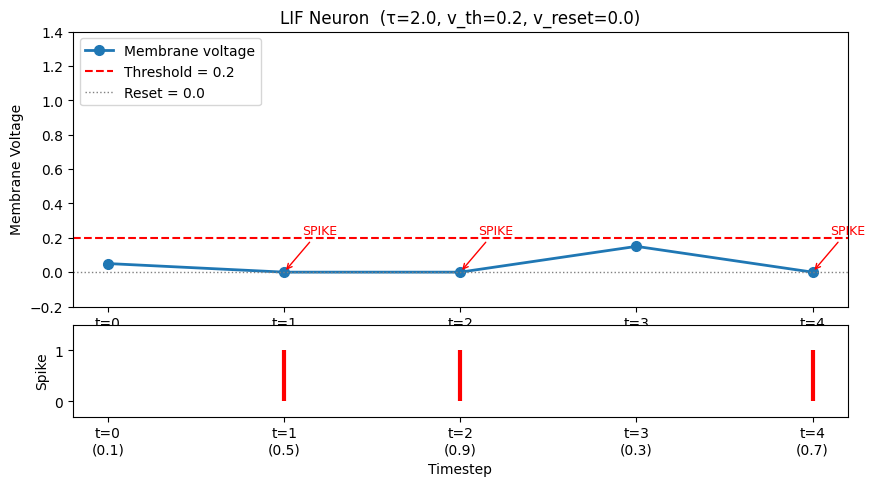

✅ Saved: outputs/plot_lif_demo.png


In [ ]:
fig = plt.figure(figsize=(10, 5))
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)

steps = list(range(len(input_signal)))

# --- Top: membrane voltage ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(steps, voltages, color="#1f77b4",
         marker="o", linewidth=2, markersize=7, label="Membrane voltage")
ax1.axhline(lif.v_threshold, color="red", linestyle="--",
            linewidth=1.5, label=f"Threshold = {lif.v_threshold}")
ax1.axhline(lif.v_reset, color="grey", linestyle=":",
            linewidth=1, label=f"Reset = {lif.v_reset}")

# Annotate spike moments
for t, (v, s) in enumerate(zip(voltages, spikes)):
    if s == 1.0:
        ax1.annotate("SPIKE", xy=(t, v),
                     xytext=(t + 0.1, lif.v_threshold * 1.1),
                     fontsize=9, color="red",
                     arrowprops=dict(arrowstyle="->", color="red"))

ax1.set_ylabel("Membrane Voltage")
ax1.set_title(f"LIF Neuron  (τ={lif.tau}, v_th={lif.v_threshold}, v_reset={lif.v_reset})")
ax1.legend(loc="upper left")
ax1.set_xticks(steps)
ax1.set_xticklabels([])
ax1.set_ylim(-0.2, 1.4)

# --- Bottom: spike train ---
ax2 = fig.add_subplot(gs[1], sharex=ax1)
spike_steps = [t for t, s in enumerate(spikes) if s == 1.0]
ax2.vlines(spike_steps, ymin=0, ymax=1,
           color="red", linewidth=3, label="Spike")
ax2.set_ylim(-0.3, 1.5)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["0", "1"])
ax2.set_ylabel("Spike")
ax2.set_xlabel("Timestep")
ax2.set_xticks(steps)
ax2.set_xticklabels([f"t={t}\n({v:.1f})" for t, v in enumerate(input_signal)])

plt.tight_layout()
# plt.savefig("../outputs/plot_lif_demo.png", bbox_inches="tight")
plt.show()
# print("✅ Saved: outputs/plot_lif_demo.png")

#### Parameter sensitivity: change tau

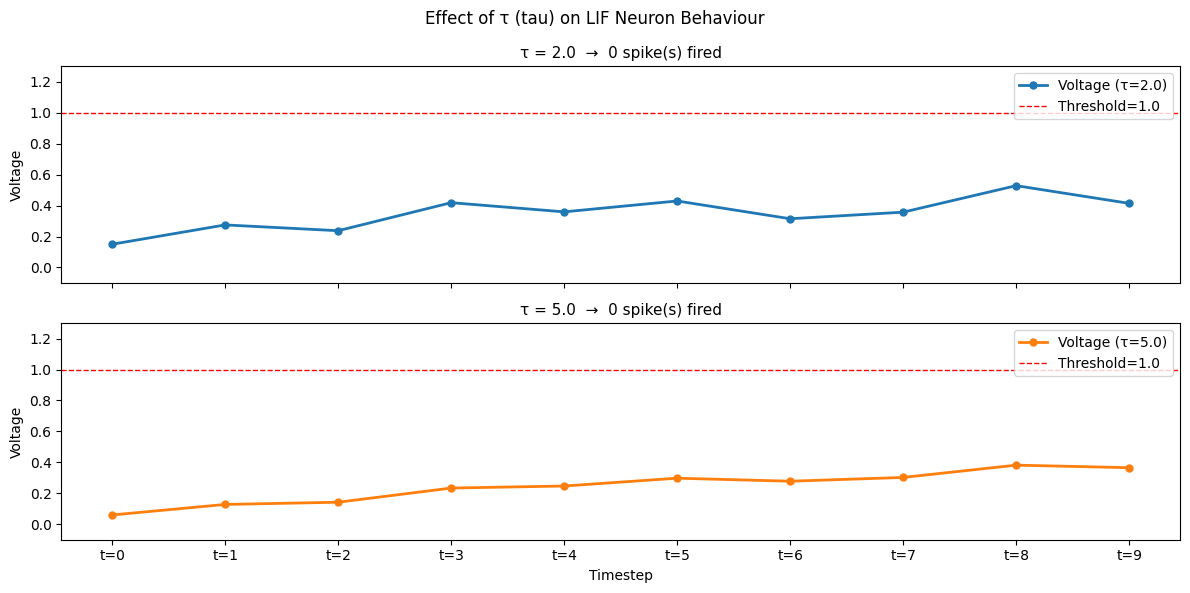

✅ Saved: outputs/plot_lif_tau_comparison.png


In [ ]:
def run_lif_sequence(input_signal, tau, v_threshold, v_reset=0.0):
    """Run a full input sequence through a fresh LIF neuron."""
    lif_test = neuron.LIFNode(tau=tau, v_threshold=v_threshold, v_reset=v_reset)
    functional.reset_net(lif_test)

    voltages, spikes = [], []
    for x in input_signal:
        x_t   = torch.tensor([[x]], dtype=torch.float32)
        s_out = lif_test(x_t)
        voltages.append(lif_test.v.item())
        spikes.append(s_out.item())

    return voltages, spikes

# Use a longer, richer signal to see the difference clearly
test_signal = [0.3, 0.4, 0.2, 0.6, 0.3, 0.5, 0.2, 0.4, 0.7, 0.3]
steps       = list(range(len(test_signal)))
tau_values  = [2.0, 5.0]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
colors    = ["#1f77b4", "#ff7f0e"]

for ax, tau, color in zip(axes, tau_values, colors):
    v_list, s_list = run_lif_sequence(test_signal, tau=tau, v_threshold=1.0)

    ax.plot(steps, v_list, color=color, marker="o",
            linewidth=2, markersize=5, label=f"Voltage (τ={tau})")
    ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="Threshold=1.0")

    # Mark spikes
    for t, s in enumerate(s_list):
        if s == 1.0:
            ax.axvline(t, color="red", linewidth=1.5, alpha=0.5)

    n_spikes = int(sum(s_list))
    ax.set_title(f"τ = {tau}  →  {n_spikes} spike(s) fired", fontsize=11)
    ax.set_ylabel("Voltage")
    ax.set_ylim(-0.1, 1.3)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Timestep")
axes[-1].set_xticks(steps)
axes[-1].set_xticklabels([f"t={t}" for t in steps])

fig.suptitle("Effect of τ (tau) on LIF Neuron Behaviour", fontsize=12)
plt.tight_layout()
# plt.savefig("../outputs/plot_lif_tau_comparison.png", bbox_inches="tight")
plt.show()
# print("✅ Saved: outputs/plot_lif_tau_comparison.png")

#### Parameter sensitivity: change v_threshold

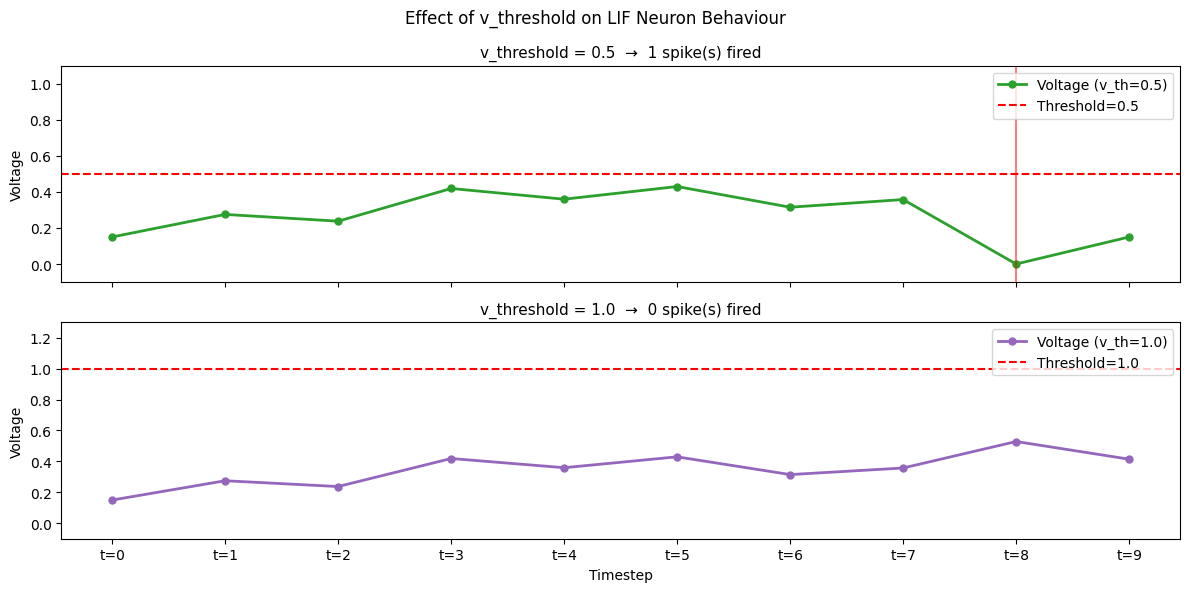

✅ Saved: outputs/plot_lif_threshold_comparison.png


In [ ]:
threshold_values = [0.5, 1.0]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
colors    = ["#2ca02c", "#9467bd"]

for ax, v_th, color in zip(axes, threshold_values, colors):
    v_list, s_list = run_lif_sequence(test_signal, tau=2.0, v_threshold=v_th)
    ax.plot(steps, v_list, color=color, marker="o",
            linewidth=2, markersize=5, label=f"Voltage (v_th={v_th})")
    ax.axhline(v_th, color="red", linestyle="--",
               linewidth=1.5, label=f"Threshold={v_th}")

    for t, s in enumerate(s_list):
        if s == 1.0:
            ax.axvline(t, color="red", linewidth=1.5, alpha=0.5)

    n_spikes = int(sum(s_list))
    ax.set_title(f"v_threshold = {v_th}  →  {n_spikes} spike(s) fired", fontsize=11)
    ax.set_ylabel("Voltage")
    ax.set_ylim(-0.1, max(v_th * 1.3, 1.1))
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Timestep")
axes[-1].set_xticks(steps)
axes[-1].set_xticklabels([f"t={t}" for t in steps])

fig.suptitle("Effect of v_threshold on LIF Neuron Behaviour", fontsize=12)
plt.tight_layout()
# plt.savefig("../outputs/plot_lif_threshold_comparison.png", bbox_inches="tight")
plt.show()
# print("✅ Saved: outputs/plot_lif_threshold_comparison.png")

#### Summary table

In [ ]:
print("=" * 60)
print("PARAMETER SENSITIVITY SUMMARY")
print("=" * 60)

configs = [
    (2.0, 0.5),
    (2.0, 1.0),
    (5.0, 0.5),
    (5.0, 1.0),
]

print(f"{'tau':>6}  {'v_thresh':>10}  {'Spikes':>8}  {'Interpretation'}")
print("-" * 60)

for tau, v_th in configs:
    _, s_list = run_lif_sequence(test_signal, tau=tau, v_threshold=v_th)
    n = int(sum(s_list))
    if tau == 2.0 and v_th == 0.5:
        note = "Fires often — sensitive, short memory"
    elif tau == 2.0 and v_th == 1.0:
        note = "Selective + short memory"
    elif tau == 5.0 and v_th == 0.5:
        note = "Fires often — sensitive, long memory"
    else:
        note = "Most selective — long memory"
    print(f"{tau:>6}  {v_th:>10}  {n:>8}  {note}")

print("=" * 60)
print("\nFor our FX settlement SNN we will use:")
print("  tau         = 2.0  (recent returns matter more than old ones)")
print("  v_threshold = 1.0  (fire only on meaningful accumulated signal)")
print("  These are starting values — we will tune them in Month 2.")


PARAMETER SENSITIVITY SUMMARY
   tau    v_thresh    Spikes  Interpretation
------------------------------------------------------------
   2.0         0.5         1  Fires often — sensitive, short memory
   2.0         1.0         0  Selective + short memory
   5.0         0.5         0  Fires often — sensitive, long memory
   5.0         1.0         0  Most selective — long memory

For our FX settlement SNN we will use:
  tau         = 2.0  (recent returns matter more than old ones)
  v_threshold = 1.0  (fire only on meaningful accumulated signal)
  These are starting values — we will tune them in Month 2.


'\n\n---\n\n**Cell 8 — Make this a Markdown cell in your notebook**\n```\n## What tau and v_threshold mean in plain English\n\n**tau (τ) — the memory knob:**\ntau controls how fast the neuron forgets old input.\nWith tau=2.0, yesterday\'s price signal barely influences today\'s voltage —\nthe neuron lives mostly in the present.\nWith tau=5.0, old signals linger — the neuron "remembers" a week of moves.\nFor INR/BRL settlement, we want tau≈2.0: recent volatility matters,\nbut last week\'s calm shouldn\'t mask today\'s crisis.\n\n**v_threshold — the sensitivity knob:**\nv_threshold is how much accumulated signal is needed before the neuron fires.\nLow threshold (0.5) → fires on small moves → noisy, too many spikes.\nHigh threshold (1.0) → only fires when signal has genuinely built up →\nspikes are rare and informative.\nThis maps directly to our manual encoder: threshold = "is this move big enough\nto matter for a settlement decision?"\n\n**The key insight:**\ntau and v_threshold togethe

## What tau and v_threshold 

**tau (τ) — the memory knob:**
tau controls how fast the neuron forgets old input.
With tau=2.0, yesterday's price signal barely influences today's voltage —
the neuron lives mostly in the present.
With tau=5.0, old signals linger — the neuron "remembers" a week of moves.
For INR/BRL settlement, we want tau≈2.0: recent volatility matters,
but last week's calm shouldn't mask today's crisis.

**v_threshold — the sensitivity knob:**
v_threshold is how much accumulated signal is needed before the neuron fires.
Low threshold (0.5) → fires on small moves → noisy, too many spikes.
High threshold (1.0) → only fires when signal has genuinely built up →
spikes are rare and informative.
This maps directly to our manual encoder: threshold = "is this move big enough
to matter for a settlement decision?"

**The key insight:**
tau and v_threshold together control the trade-off between sensitivity and
selectivity. In a settlement system, false positives (unnecessary holds) cost
money. We tune toward selectivity — fire less, but fire meaningfully.